# Glaucoma Detection (with Visualization and Debugging)

This notebook segments the optic cup and disc to classify glaucoma. **This version includes enhanced error checking to find specific image/mask pairs with mismatched dimensions.**

--- 
## 1. Setup and Installation 📂

In [1]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install opencv-python matplotlib tqdm albumentations ipywidgets

### Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import cv2
import numpy as np
from glob import glob
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

--- 
## 2. Data Loading (`Dataset` Class) 🖼️

This version includes robust error handling to catch missing files **and** files with mismatched height/width.

In [2]:
class GlaucomaDataset(Dataset):
    def __init__(self, image_paths, mask_root_folder, transform=None):
        self.image_paths = image_paths
        self.mask_root_folder = mask_root_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        
        if image is None:
            raise FileNotFoundError(f"Image not found or is corrupted: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        img_filename_with_ext = os.path.basename(img_path)
        base_filename, _ = os.path.splitext(img_filename_with_ext)
        mask_filename = f"{base_filename}.png"

        cup_mask_path = os.path.join(self.mask_root_folder, 'cup', mask_filename)
        disc_mask_path = os.path.join(self.mask_root_folder, 'disc', mask_filename)

        cup_mask = cv2.imread(cup_mask_path, cv2.IMREAD_GRAYSCALE)
        disc_mask = cv2.imread(disc_mask_path, cv2.IMREAD_GRAYSCALE)

        if cup_mask is None:
            raise FileNotFoundError(f"Cup mask not found or is corrupted for image {img_path}. Searched at: {cup_mask_path}")
        if disc_mask is None:
            raise FileNotFoundError(f"Disc mask not found or is corrupted for image {img_path}. Searched at: {disc_mask_path}")

        disc_mask = (disc_mask > 128).astype(np.float32)
        cup_mask = (cup_mask > 128).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, masks=[disc_mask, cup_mask])
            image = augmented['image']
            disc_mask, cup_mask = augmented['masks']

        combined_mask = torch.from_numpy(np.stack([disc_mask, cup_mask], axis=0))

        # ==================== THE FIX IS HERE ====================
        # Add img_path as the third item in the return statement
        return image, combined_mask, img_path
        # =========================================================

--- 
## 3. U-Net Model Architecture 🧠

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))
        
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5)
        x = torch.cat([x4, x], dim=1)
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv3(x)
        
        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv4(x)
        
        return self.outc(x)

--- 
## 4. Training the Model 🚀

### Hyperparameters and Configuration

In [4]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 4
EPOCHS = 50
IMG_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_DIR = "data/images"
MASK_DIR = "data/masks"
MODEL_SAVE_PATH = "unet_glaucoma_segmentation.pth"

print(f"Using device: {DEVICE}")

Using device: cuda


### Loss Function and Visualization Helper

In [5]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probas = torch.sigmoid(logits)
        probas_flat = probas.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probas_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probas_flat.sum() + targets_flat.sum() + self.smooth)
        return 1 - dice_score

def visualize_predictions(model, loader, device):
    model.eval()
    images, true_masks = next(iter(loader))
    images = images.to(device=device)

    with torch.no_grad():
        preds = model(images)
        preds = (torch.sigmoid(preds) > 0.5).float()

    image_to_plot = images[0].permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.0, 0.0, 0.0])
    std = np.array([1.0, 1.0, 1.0])
    image_to_plot = std * image_to_plot + mean
    image_to_plot = np.clip(image_to_plot, 0, 1)

    true_mask_to_plot = true_masks[0].cpu().numpy()
    pred_mask_to_plot = preds[0].cpu().numpy()

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(image_to_plot)
    plt.axis("off")

    true_overlay = np.zeros_like(image_to_plot, dtype=np.uint8)
    true_overlay[true_mask_to_plot[0].astype(bool)] = [0, 0, 255]
    true_overlay[true_mask_to_plot[1].astype(bool)] = [255, 0, 0]

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(image_to_plot)
    plt.imshow(true_overlay, alpha=0.4)
    plt.axis("off")

    pred_overlay = np.zeros_like(image_to_plot, dtype=np.uint8)
    pred_overlay[pred_mask_to_plot[0].astype(bool)] = [0, 0, 255]
    pred_overlay[pred_mask_to_plot[1].astype(bool)] = [255, 0, 0]

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(image_to_plot)
    plt.imshow(pred_overlay, alpha=0.4)
    plt.axis("off")
    
    plt.show()

    model.train()

### Training Loop

Dataset loaded: 585 training images, 64 validation images.


Epoch 1/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 2/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 3/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 4/50:   0%|          | 0/585 [00:00<?, ?img/s]

...

Epoch 7/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 8/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 9/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 10/50:   0%|          | 0/585 [00:00<?, ?img/s]


--- Visualizing Predictions for Epoch 10 ---


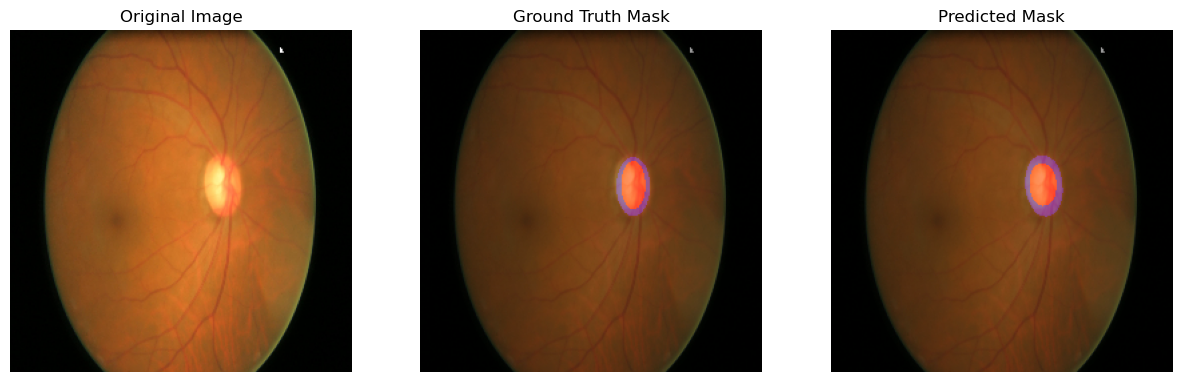

Epoch 11/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 12/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 13/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 14/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 15/50:   0%|          | 0/585 [00:00<?, ?img/s]

...

Epoch 17/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 18/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 19/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 20/50:   0%|          | 0/585 [00:00<?, ?img/s]


--- Visualizing Predictions for Epoch 20 ---


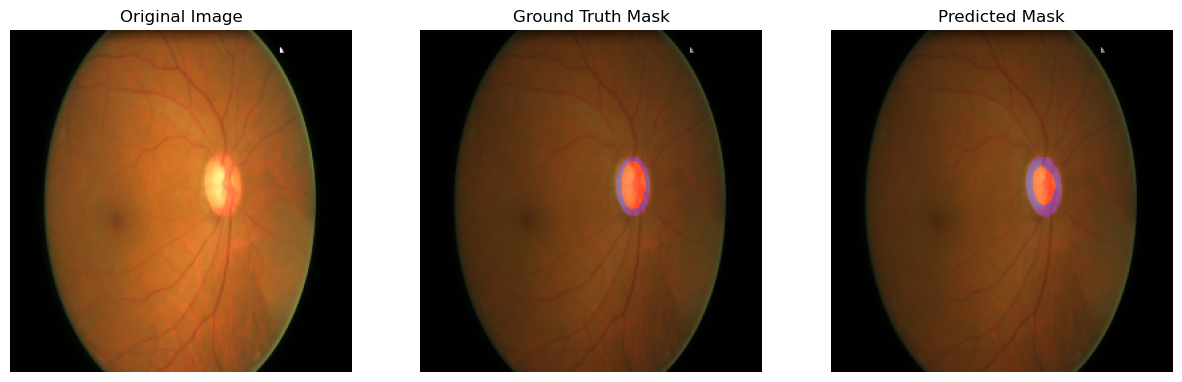

Epoch 21/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 22/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 23/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 24/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 25/50:   0%|          | 0/585 [00:00<?, ?img/s]

...

Epoch 27/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 28/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 29/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 30/50:   0%|          | 0/585 [00:00<?, ?img/s]


--- Visualizing Predictions for Epoch 30 ---


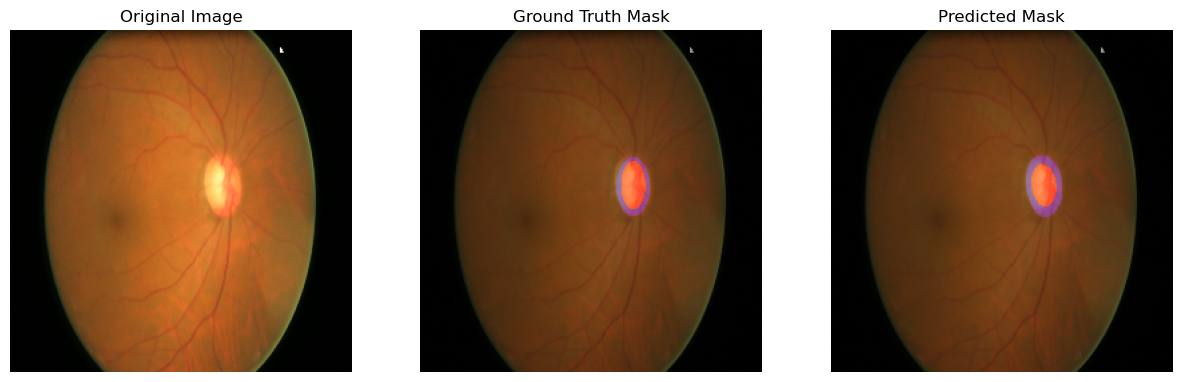

Epoch 31/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 32/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 33/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 34/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 35/50:   0%|          | 0/585 [00:00<?, ?img/s]

...

Epoch 37/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 38/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 39/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 40/50:   0%|          | 0/585 [00:00<?, ?img/s]


--- Visualizing Predictions for Epoch 40 ---


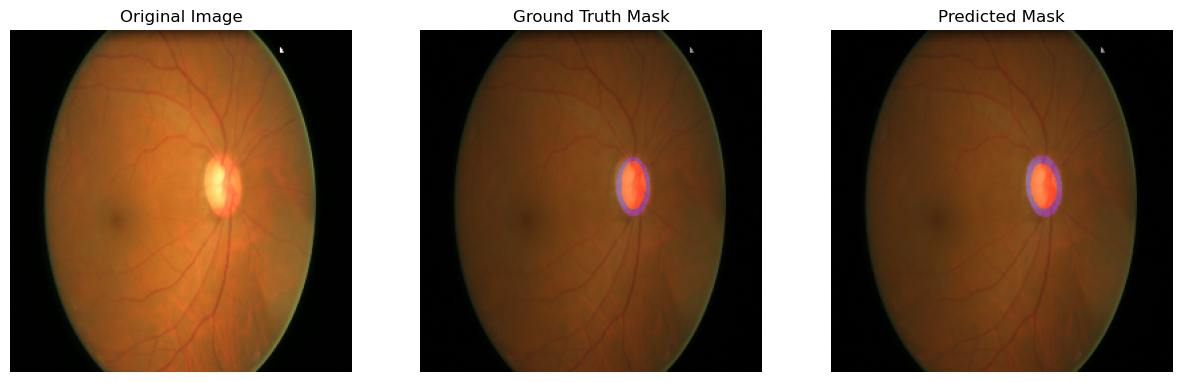

Epoch 41/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 42/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 43/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 44/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 45/50:   0%|          | 0/585 [00:00<?, ?img/s]

...

Epoch 47/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 48/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 49/50:   0%|          | 0/585 [00:00<?, ?img/s]

Epoch 50/50:   0%|          | 0/585 [00:00<?, ?img/s]


--- Visualizing Predictions for Epoch 50 ---


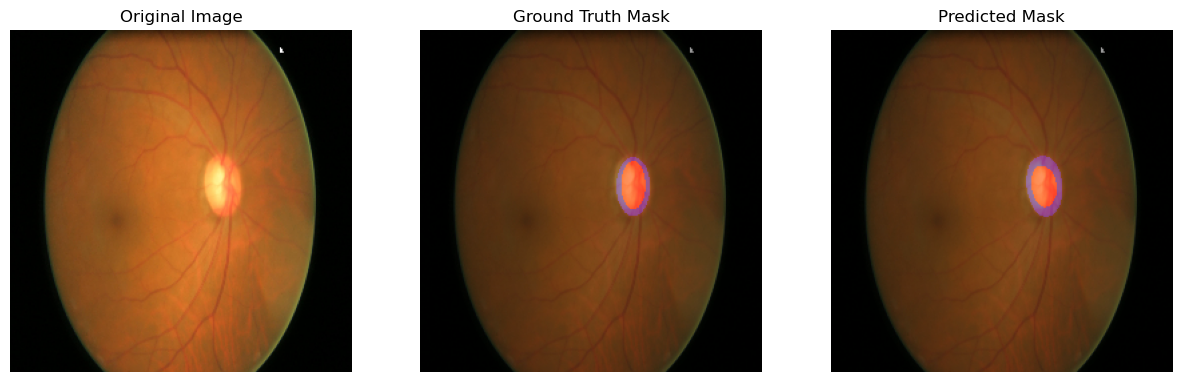


Training complete. Model saved to unet_glaucoma_segmentation.pth


In [7]:
train_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

all_image_paths = glob(os.path.join(IMAGE_DIR, "*.jpg")) + glob(os.path.join(IMAGE_DIR, "*.png"))

val_percent = 0.1
if not all_image_paths:
    print("ERROR: No images found in the data/images directory. Please add your images.")
else:
    n_val = int(len(all_image_paths) * val_percent)
    if n_val == 0:
        n_val = 1 # Ensure at least one validation sample if dataset is small
    n_train = len(all_image_paths) - n_val
    
    if n_train > 0:
        train_paths, val_paths = random_split(all_image_paths, [n_train, n_val])
        train_set = GlaucomaDataset(list(train_paths), MASK_DIR, transform=train_transform)
        val_set = GlaucomaDataset(list(val_paths), MASK_DIR, transform=val_transform)

        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        print(f"Dataset loaded: {len(train_set)} training images, {len(val_set)} validation images.")

        model = UNet(n_channels=3, n_classes=2).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        bce_loss = nn.BCEWithLogitsLoss()
        dice_loss = DiceLoss()

        for epoch in range(EPOCHS):
            model.train()
            with tqdm(total=len(train_set), desc=f'Epoch {epoch + 1}/{EPOCHS}', unit='img') as pbar:
                for images, true_masks in train_loader:
                    images = images.to(device=DEVICE)
                    true_masks = true_masks.to(device=DEVICE)

                    pred_masks = model(images)
                    loss = bce_loss(pred_masks, true_masks) + dice_loss(pred_masks, true_masks)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    
                    pbar.update(images.shape[0])
                    pbar.set_postfix(**{'loss (batch)': loss.item()})

            if (epoch + 1) % 10 == 0:
                print(f"\n--- Visualizing Predictions for Epoch {epoch + 1} ---")
                visualize_predictions(model, val_loader, device=DEVICE)

        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\nTraining complete. Model saved to {MODEL_SAVE_PATH}")
    else:
        print("ERROR: Not enough images to create a training set. Please add more images.")

--- 
## 5. Evaluation and Classification 🎯

In [6]:
def classify_image(image_path, model, device, cdr_threshold):
    original_image = cv2.imread(image_path)
    if original_image is None:
        print(f"Error: Could not read image at {image_path}")
        return
        
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    h, w, _ = original_image.shape

    eval_transform = A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
        ToTensorV2(),
    ])
    
    input_tensor = eval_transform(image=original_image_rgb)["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(input_tensor)
        pred_masks = (torch.sigmoid(preds) > 0.5).float().squeeze(0).cpu().numpy()

    disc_mask = cv2.resize(pred_masks[0], (w, h), interpolation=cv2.INTER_NEAREST)
    cup_mask = cv2.resize(pred_masks[1], (w, h), interpolation=cv2.INTER_NEAREST)

    cup_mask_cleaned = np.logical_and(cup_mask, disc_mask)
    disc_area = np.sum(disc_mask)
    cup_area = np.sum(cup_mask_cleaned)
    cdr = cup_area / disc_area if disc_area > 0 else 0.0
    
    is_glaucomatous = cdr > cdr_threshold
    result_text = "Glaucomatous" if is_glaucomatous else "Normal"
    
    print(f"--- Analysis for {os.path.basename(image_path)} ---")
    print(f"Disc Area: {disc_area:.0f} pixels")
    print(f"Cup Area: {cup_area:.0f} pixels")
    print(f"Cup-to-Disc Ratio (CDR): {cdr:.4f}")
    print(f"Result: {result_text} (Threshold > {cdr_threshold})")

    overlay = original_image_rgb.copy()
    overlay[disc_mask.astype(bool)] = (0, 100, 255) 
    overlay[cup_mask_cleaned.astype(bool)] = (255, 100, 0)
    
    blended = cv2.addWeighted(original_image_rgb, 0.6, overlay, 0.4, 0)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(blended)
    plt.title(f'Result: {result_text} (CDR: {cdr:.2f})')
    plt.axis('off')
    plt.show()

In [13]:
import scipy.io

mat_file_path = r'ORIGA\OrigaList.mat' # <-- Make sure this filename is correct

try:
    data = scipy.io.loadmat(mat_file_path)
    print(f"Successfully loaded {mat_file_path}")
    print("-----------------------------------------")
    
    # Print all the variable names (keys) found in the file
    print(f"Available keys are: {list(data.keys())}")
    print("-----------------------------------------")

    # Let's inspect the shape and type of each variable
    for key in data:
        if not key.startswith('__'): # Ignore metadata keys
            print(f"Inspecting key: '{key}'")
            print(f"  - Shape: {data[key].shape}")
            print(f"  - Data type: {data[key].dtype}")
            # Print the first few items to see the content
            try:
                print(f"  - Example content: {data[key][0:3]}")
            except Exception:
                print("  - (Could not show example content)")
            print("")

except FileNotFoundError:
    print(f"ERROR: The file '{mat_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded ORIGA\OrigaList.mat
-----------------------------------------
Available keys are: ['__header__', '__version__', '__globals__', 'Origa']
-----------------------------------------
Inspecting key: 'Origa'
  - Shape: (1, 650)
  - Data type: [('Eye', 'O'), ('Filename', 'O'), ('ExpCDR', 'O'), ('Set', 'O'), ('Glaucoma', 'O')]
  - Example content: [[(array(['OD'], dtype='<U2'), array(['001.jpg'], dtype='<U7'), array([[0.7097]]), array(['A'], dtype='<U1'), array([[0]], dtype=uint8))
  (array(['OS'], dtype='<U2'), array(['002.jpg'], dtype='<U7'), array([[0.6953]]), array(['A'], dtype='<U1'), array([[0]], dtype=uint8))
  (array(['OS'], dtype='<U2'), array(['003.jpg'], dtype='<U7'), array([[0.9629]]), array(['A'], dtype='<U1'), array([[0]], dtype=uint8))
  (array(['OD'], dtype='<U2'), array(['004.jpg'], dtype='<U7'), array([[0.7246]]), array(['A'], dtype='<U1'), array([[0]], dtype=uint8))
  (array(['OS'], dtype='<U2'), array(['005.jpg'], dtype='<U7'), array([[0.6138]]), array([

### Run Classification on a Test Image

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix

def get_dice_score(preds, targets, smooth=1e-6):
    """Calculates the Dice score for a batch of predictions and targets."""
    preds = preds.contiguous().view(-1)
    targets = targets.contiguous().view(-1)
    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice.item()

def evaluate_and_collect_cdrs(model, loader, device, labels_df):
    """
    Evaluates the model to collect true labels and all calculated CDRs.
    """
    model.eval()
    y_true, all_cdrs = [], []
    labels_dict = labels_df.set_index('image_name')['is_glaucoma'].to_dict()

    with torch.no_grad():
        for images, true_masks, paths in tqdm(loader, desc="Collecting CDRs"):
            images = images.to(device)
            preds = model(images)
            pred_masks = (torch.sigmoid(preds) > 0.5).float()

            for i in range(images.shape[0]):
                disc_area = pred_masks[i, 0, :, :].sum()
                cup_area = pred_masks[i, 1, :, :].sum()
                cdr = (cup_area / disc_area).item() if disc_area > 0 else 0
                all_cdrs.append(cdr)
                
                image_filename = os.path.basename(paths[i])
                true_label = labels_dict.get(image_filename)
                if true_label is not None:
                    y_true.append(true_label)
    
    return y_true, all_cdrs

In [18]:
print("Preparing data loaders for evaluation...")

# Define transformations (needed for the test set)
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2(),
])

# --- Re-create the data split to include a test set ---
all_image_paths = glob(os.path.join(IMAGE_DIR, "*.jpg")) + glob(os.path.join(IMAGE_DIR, "*.png"))

# Define the split percentages
val_percent = 0.15
test_percent = 0.15
n_total = len(all_image_paths)
n_test = int(n_total * test_percent)
n_val = int(n_total * val_percent)
n_train = n_total - n_val - n_test

# IMPORTANT: To ensure you test on the same data every time, we set a manual seed
train_paths, val_paths, test_paths = random_split(
    all_image_paths, 
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42) # This keeps the split consistent
)

# Create the test set and loader
test_set = GlaucomaDataset(list(test_paths), MASK_DIR, transform=val_transform)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data split is ready for testing: {len(test_set)} images in the test set.")
print("The 'test_loader' variable is now defined. You can proceed with the final evaluation.")

Preparing data loaders for evaluation...
Data split is ready for testing: 97 images in the test set.
The 'test_loader' variable is now defined. You can proceed with the final evaluation.


In [11]:
# --- Main Evaluation Execution ---
CDR_THRESHOLD = 0.6
LABELS_MAT_FILE = "OrigaList.mat" # <-- The name of your single .mat file

if os.path.exists(MODEL_SAVE_PATH):
    # Load labels from the single origalist.mat file
    labels_df = load_labels_from_origa_mat(LABELS_MAT_FILE)
    
    if not labels_df.empty:
        # Load the best model
        eval_model = UNet(n_channels=3, n_classes=2).to(DEVICE)
        eval_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
        
        # Run the evaluation on the test_loader
        evaluate_model(eval_model, test_loader, DEVICE, 0.55, labels_df)
    else:
        print("Could not load labels from the .mat file. Cannot calculate classification accuracy.")
else:
    print(f"Model file not found at {MODEL_SAVE_PATH}. Please train the model first.")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_13832\2527805230.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eval_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map

Evaluating on Test Set:   0%|          | 0/25 [00:00<?, ?it/s]


--- Test Set Evaluation Results ---
Segmentation Performance:
  - Average Optic Disc Dice Score: 0.8956
  - Average Optic Cup Dice Score:  0.9156

Classification Performance (CDR Threshold = 0.55):
  - Accuracy:    0.7526
  - Sensitivity (Recall): 0.7419
  - Specificity: 0.7576


In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Run this after training is complete ---
# First, collect the true labels and predicted CDRs from your test set
y_true, all_cdrs = evaluate_and_collect_cdrs(eval_model, test_loader, DEVICE, labels_df)

# Now, test a range of thresholds
thresholds_to_test = [0.60, 0.55, 0.50, 0.45, 0.40, 0.35]

print("\n--- Threshold Analysis ---")
for threshold in thresholds_to_test:
    # Classify based on the current threshold
    y_pred = [1 if cdr > threshold else 0 for cdr in all_cdrs]
    
    if len(y_true) == len(y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"Threshold: {threshold:.2f} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")


--- Threshold Analysis ---
Threshold: 0.60 | Sensitivity: 0.6774 | Specificity: 0.8030
Threshold: 0.55 | Sensitivity: 0.7419 | Specificity: 0.7576
Threshold: 0.50 | Sensitivity: 0.8387 | Specificity: 0.7424
Threshold: 0.45 | Sensitivity: 0.9677 | Specificity: 0.6515
Threshold: 0.40 | Sensitivity: 1.0000 | Specificity: 0.4091
Threshold: 0.35 | Sensitivity: 1.0000 | Specificity: 0.2879


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

# The new threshold to test
threshold = 0.45

# Classify based on the new threshold
y_pred = [1 if cdr > threshold else 0 for cdr in all_cdrs]

if len(y_true) == len(y_pred):
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"--- Results for Threshold: {threshold:.2f} ---")
    print(f"  - Accuracy:    {accuracy:.4f}")
    print(f"  - Sensitivity: {sensitivity:.4f}")
    print(f"  - Specificity: {specificity:.4f}")

--- Results for Threshold: 0.45 ---
  - Accuracy:    0.7526
  - Sensitivity: 0.9677
  - Specificity: 0.6515
